In [2]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";

In [3]:
using Revise

In [4]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [31]:
ks, _, iGarr = gvectors("./LDA/BN22BC-0.0");
iGarr_gamma = np.array(iGarr[13]);

In [32]:
ks

38-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0]
 [0.0, 0.0833333, 0.0]
 [0.0, 0.1666667, 0.0]
 [0.0, 0.25, 0.0]
 [0.0, 0.3333333, 0.0]
 [0.0, 0.4166667, 0.0]
 [0.0, 0.5, 0.0]
 [0.0833333, 0.0833333, 0.0]
 [0.0833333, 0.1666667, 0.0]
 [0.0833333, 0.25, 0.0]
 [0.0833333, 0.3333333, 0.0]
 [0.0833333, 0.4166667, 0.0]
 [0.1666667, 0.1666667, 0.0]
 ⋮
 [0.0833333, 0.0833333, 0.0]
 [0.0833333, 0.1666667, 0.0]
 [0.0833333, 0.25, 0.0]
 [0.0833333, 0.3333333, 0.0]
 [0.0833333, 0.4166667, 0.0]
 [0.1666667, 0.1666667, 0.0]
 [0.1666667, 0.25, 0.0]
 [0.1666667, 0.3333333, 0.0]
 [0.1666667, 0.4166667, 0.0]
 [0.25, 0.25, 0.0]
 [0.25, 0.3333333, 0.0]
 [0.3333333, 0.3333333, 0.0]

In [33]:
Ckb_up = return_cg("./LDA/BN22BC-0.0", ks, iGarr,  [0.1666667, 0.1666667, 0.0], 17, 32, Val('u'));
Ckb_dn = return_cg("./LDA/BN22BC-0.0", ks, iGarr, [0.1666667, 0.1666667, 0.0], 17, 32, Val('d'));

In [34]:
wfn_up = JJDFTX.real_space_wfn(Ckb_up, iGarr_gamma, [40, 40, 168])
wfn_squared_up = (abs.(wfn_up)).^2
wfn_squared_up *= length(wfn_squared_up); # Make it so wfn squared is probability density at each point

wfn_dn = JJDFTX.real_space_wfn(Ckb_dn, iGarr_gamma, [40, 40, 168])
wfn_squared_dn = (abs.(wfn_dn)).^2
wfn_squared_dn *= length(wfn_squared_dn); # Make it so wfn squared is probability density at each point


In [44]:
splits = Float64[]
x = Float64[]
for i in 10:41
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)
    
    Ckb_up = return_cg("./LDA/BN22BC-$charge", ks, iGarr,  [0.1666667, 0.1666667, 0.0], 17, 32, Val('u'));
    Ckb_dn = return_cg("./LDA/BN22BC-$charge", ks, iGarr, [0.1666667, 0.1666667, 0.0], 17, 32, Val('d'));
    wfn_up = JJDFTX.real_space_wfn(Ckb_up, iGarr_gamma, [40, 40, 168])
    wfn_squared_up = (abs.(wfn_up)).^2
    wfn_squared_up *= length(wfn_squared_up); # Make it so wfn squared is probability density at each point

    wfn_dn = JJDFTX.real_space_wfn(Ckb_dn, iGarr_gamma, [40, 40, 168])
    wfn_squared_dn = (abs.(wfn_dn)).^2
    wfn_squared_dn *= length(wfn_squared_dn); # Make it so wfn squared is probability density at each point

    filename_eigenvals = "./LDA/BN22BC-$(charge).eigenvals"
    
    filename_nup = "./LDA/BN22BC-$(charge).n_up"
    
    filename_ndn = "./LDA/BN22BC-$(charge).n_dn"

    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)
        
    n_up = np.reshape(n_up, [40, 40, 168])
    n_dn = np.reshape(n_dn, [40, 40, 168])

    diff = abs(sum(wfn_squared_up.*n_up.^(1/3) - wfn_squared_dn.*n_dn.^(1/3)))*3032.71/length(n_dn)

    push!(x, diff)
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 32, 19, spin=2);
    push!(splits, abs(mean(data[2][17]) - mean(data[1][17])))
end

Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41


In [45]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = true;

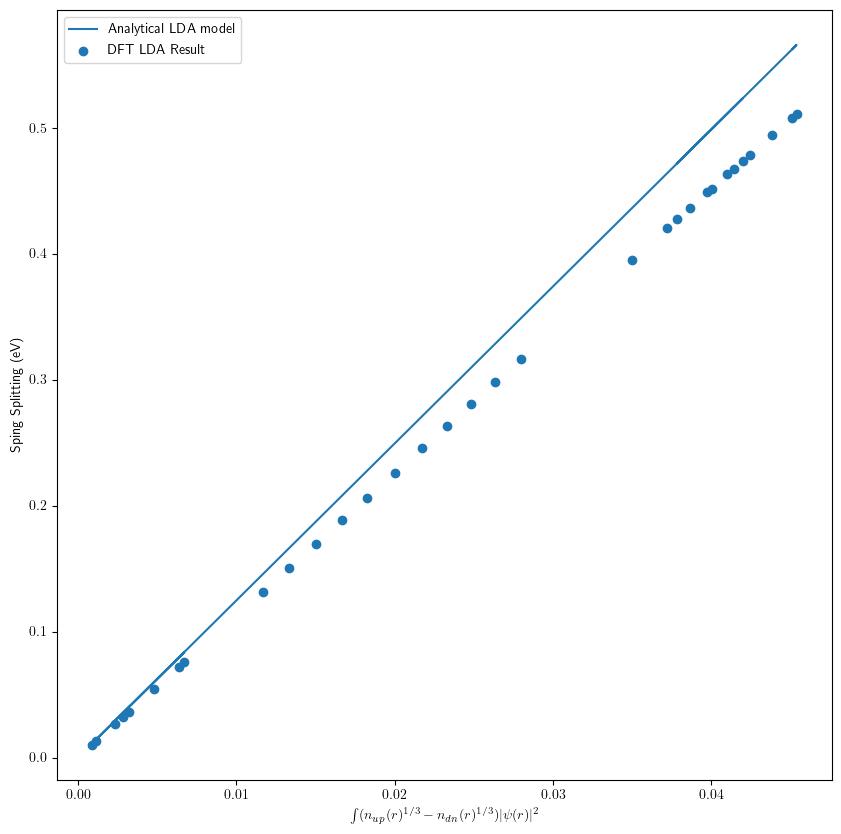

PyObject <matplotlib.legend.Legend object at 0x7f05b0283910>

In [46]:
figure(figsize=(10, 10))
scatter(x, splits, label="DFT LDA Result")

plot(x, x*0.458*1/eV, label="Analytical LDA model")
ylabel("Sping Splitting (eV)")

xlabel(L"\int (n_{up}(r)^{1/3}-n_{dn}(r)^{1/3})|\psi(r)|^2")
legend()

In [47]:
splits = Float64[]
x = Float64[]
for i in 10:41
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)
    
    Ckb_up = return_cg("BN22BC-$charge", ks, iGarr,  [0.1666667, 0.1666667, 0.0], 17, 32, Val('u'));
    Ckb_dn = return_cg("BN22BC-$charge", ks, iGarr, [0.1666667, 0.1666667, 0.0], 17, 32, Val('d'));
    wfn_up = JJDFTX.real_space_wfn(Ckb_up, iGarr_gamma, [40, 40, 168])
    wfn_squared_up = (abs.(wfn_up)).^2
    wfn_squared_up *= length(wfn_squared_up); # Make it so wfn squared is probability density at each point

    wfn_dn = JJDFTX.real_space_wfn(Ckb_dn, iGarr_gamma, [40, 40, 168])
    wfn_squared_dn = (abs.(wfn_dn)).^2
    wfn_squared_dn *= length(wfn_squared_dn); # Make it so wfn squared is probability density at each point

    filename_eigenvals = "BN22BC-$(charge).eigenvals"
    
    filename_nup = "BN22BC-$(charge).n_up"
    
    filename_ndn = "BN22BC-$(charge).n_dn"

    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)
        
    n_up = np.reshape(n_up, [40, 40, 168])
    n_dn = np.reshape(n_dn, [40, 40, 168])

    diff = abs(sum(wfn_squared_up.*n_up.^(1/3) - wfn_squared_dn.*n_dn.^(1/3)))*3032.71/length(n_dn)

    push!(x, diff)
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 32, 19, spin=2);
    push!(splits, abs(mean(data[2][17]) - mean(data[1][17])))
end

Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41


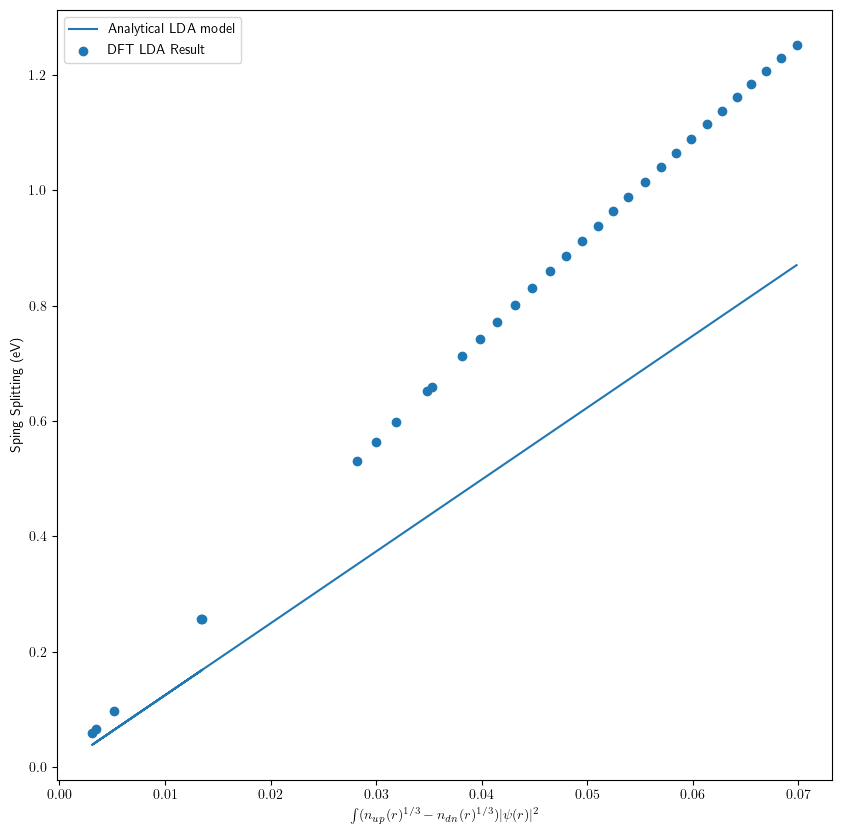

PyObject <matplotlib.legend.Legend object at 0x7f05b01e87c0>

In [48]:
figure(figsize=(10, 10))
scatter(x, splits, label="DFT LDA Result")

plot(x, x*0.458*1/eV, label="Analytical LDA model")
ylabel("Sping Splitting (eV)")

xlabel(L"\int (n_{up}(r)^{1/3}-n_{dn}(r)^{1/3})|\psi(r)|^2")
legend()